In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_rows', None)    # Display all rows
pd.set_option('display.max_columns', None) # Display all columns
pd.set_option('display.expand_frame_repr', False) # Prevent wrapping of columns

In [3]:
pip install pandas odfpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 31.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for odfpy: filename=odfpy-1.4.1-py2.py3-none-any.whl size=160672 sha256=2f93af64b298ec653a4da4ca43e8ae29d6d1029e1c839105148846f2d042a0fd
  Stored in directory: /root/.cache/pip/wheels/c8/2e/95/90d94fe33903786937f3b8c33dd88807f792359c6424b40469
Successfully built odfpy


In [4]:
ods_f_path = "/content/Zadanie_bonus.ods"

In [5]:
csv_file = "output_file.csv"

In [6]:
df = pd.read_excel(ods_f_path, engine='odf')

In [7]:
df.to_csv(csv_file, index=False)

In [9]:
df.head()

,Značka,Produkt,MEDIATYP_group,Rok,Mesiac,SPONZORING_group,POZICIE_group,TV_group,Cena db,TRP bloku_M 25-50
0,RADEGAST,RADEGAST RYZE HORKA 12,01_TV,2021,máj,Kampaň,Pozicie,Markíza Group,321349,147.841990
1,VELKOPOPOVICKY KOZEL,VELKOPOPOVICKY KOZEL MISTRUV LEZAK,01_TV,2021,marec,Kampaň,Pozicie,Markíza Group,272630,123.554255
2,RADEGAST,RADEGAST RYZE HORKA 12,01_TV,2021,máj,Kampaň,Pozicie,Markíza Group,262529,123.861786
3,VELKOPOPOVICKY KOZEL,VELKOPOPOVICKY KOZEL MISTRUV LEZAK,01_TV,2021,apríl,Kampaň,Pozicie,Markíza Group,257660,113.635585
4,VELKOPOPOVICKY KOZEL,VELKOPOPOVICKY KOZEL MISTRUV LEZAK,01_TV,2021,marec,Kampaň,Pozicie,Markíza Group,248444,112.185038


# 2. Použi AVERAGEIFS na výpočet priemerných TRPs CS značiek po rokoch.
# 3. Použi SUMIFS na výpočet sumy (cena) značiek po rokoch a iba za kampane

In [10]:
df_filtered = df[df["Rok"].isin([2021, 2022])]
df_campaign = df_filtered[df_filtered["SPONZORING_group"] == "Kampaň"]

avg_trp = df_filtered.groupby(["Značka", "Rok"])["TRP bloku_M 25-50"].mean().reset_index()
avg_trp.rename(columns={"TRP bloku_M 25-50": "Average TRP bloku_M 25-50"}, inplace=True)

total_cena_db = df_campaign.groupby(["Značka", "Rok"])["Cena db"].sum().reset_index()
total_cena_db.rename(columns={"Cena db": "Total Cena db (Kampaň)"}, inplace=True)
summary_table = pd.merge(avg_trp, total_cena_db, on=["Značka", "Rok"], how="outer")

print(summary_table)

                  Značka   Rok  Average TRP bloku_M 25-50  Total Cena db (Kampaň)
0                 CORGON  2021                  12.408166                  207996
1                 CORGON  2022                  26.551059                   40935
2               HEINEKEN  2022                  14.902380                  942511
3            KALTENECKER  2021                        NaN                    6124
4              KRUSOVICE  2021                  20.340319                  938739
5              KRUSOVICE  2022                  22.683295                 1729375
6               KUKKONIA  2022                        NaN                     875
7               RADEGAST  2021                  13.482120                 4739820
8               RADEGAST  2022                   9.219141                 5539034
9                  SARIS  2021                  10.124715                 1078222
10                 SARIS  2022                        NaN                    2091
11              

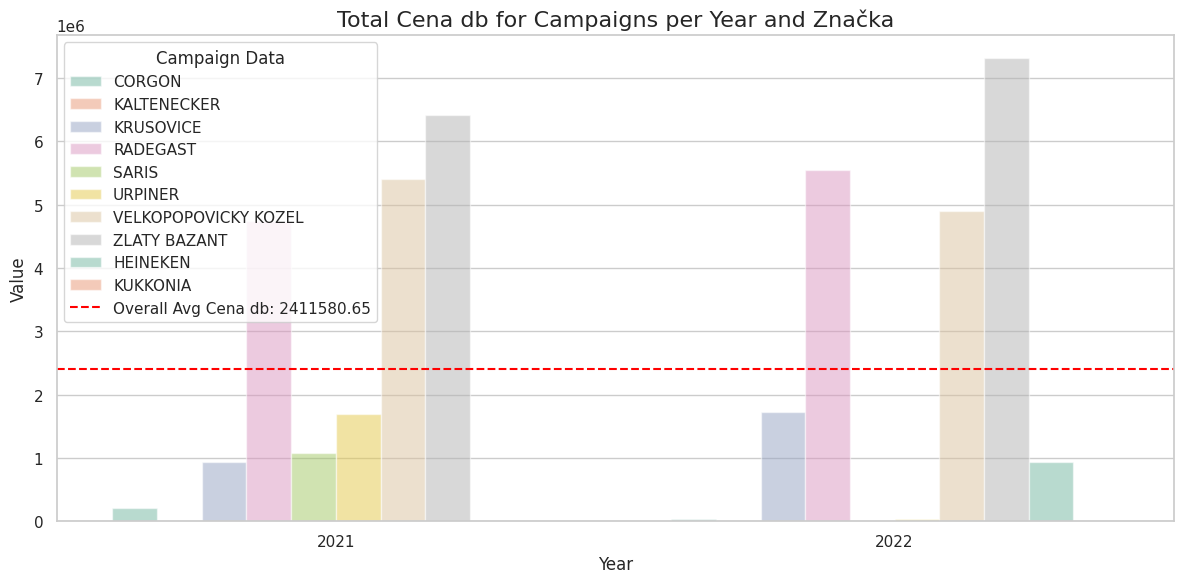

In [16]:

overall_avg_cena_db = total_cena_db['Total Cena db (Kampaň)'].mean()

sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.barplot(x='Rok', y='Total Cena db (Kampaň)', hue='Značka', data=summary_table, ci=None, palette='Set2', alpha=0.5)
plt.axhline(overall_avg_cena_db, color='red', linestyle='--', label=f'Overall Avg Cena db: {overall_avg_cena_db:.2f}')


plt.title('Total Cena db for Campaigns per Year and Značka', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(title='Campaign Data', loc='upper left')

plt.tight_layout()
plt.show()

# 4. Použi COUNTIFS na výpočet počtu kampaní vs sponzoringu po značkách a rokoch.

In [12]:

df_sponzoring = df_filtered[df_filtered["SPONZORING_group"] == "Sponzoring"]

count_sponzoring = df_sponzoring.groupby(["Značka", "Rok"])["SPONZORING_group"].count().reset_index(name="Sponzoring_count")
count_kampan = df_campaign.groupby(["Značka", "Rok"])["SPONZORING_group"].count().reset_index(name="Kampan_count")

summary_table_count_s = pd.merge(summary_table, count_sponzoring, on=["Značka", "Rok"], how="outer")
summary_table_count_k = pd.merge(summary_table, count_kampan, on=["Značka", "Rok"], how="outer")

final_summary_table = pd.merge(summary_table_count_s, summary_table_count_k, on=["Značka", "Rok"], how="outer")

print(final_summary_table)

                  Značka   Rok  Average TRP bloku_M 25-50_x  Total Cena db (Kampaň)_x  Sponzoring_count  Average TRP bloku_M 25-50_y  Total Cena db (Kampaň)_y  Kampan_count
0                 CORGON  2021                    12.408166                    207996               NaN                    12.408166                    207996            12
1                 CORGON  2022                    26.551059                     40935               NaN                    26.551059                     40935             3
2               HEINEKEN  2022                    14.902380                    942511               NaN                    14.902380                    942511            42
3            KALTENECKER  2021                          NaN                      6124               NaN                          NaN                      6124             3
4              KRUSOVICE  2021                    20.340319                    938739               NaN                    20.340319   

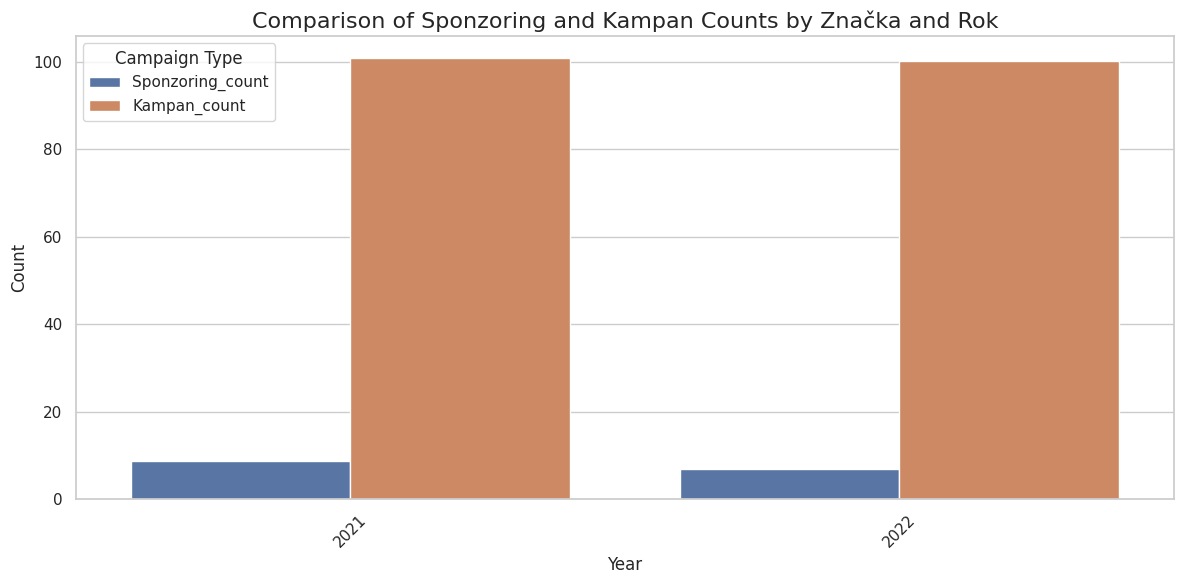

In [13]:
import seaborn as sns

df_to_plot = final_summary_table[['Značka', 'Rok', 'Sponzoring_count', 'Kampan_count']]
df_melted = df_to_plot.melt(id_vars=['Značka', 'Rok'], value_vars=['Sponzoring_count', 'Kampan_count'],
                            var_name='Campaign Type', value_name='Count')

sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(x='Rok', y='Count', hue='Campaign Type', data=df_melted, ci=None)

plt.title('Comparison of Sponzoring and Kampan Counts by Značka and Rok', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Campaign Type')


plt.tight_layout()
plt.show()